### Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!apt-get install unrar tree
!pip install ipecharts

### Data Extract

In [ ]:
!unrar x /content/drive/MyDrive/TUKL/data_online_line_width_alpha.rar "*.csv" /content/
!mv /content/data_online_line_width_alpha/ /content/hwd/

In [4]:
!tree -L 1 /content/hwd/

/content/hwd/
├── Dataset
├── main_1000.csv
├── main_1500.csv
├── main_2000.csv
├── main_2500.csv
├── main_3000.csv
├── main_3500.csv
├── main_5000.csv
├── main_6000.csv
├── test.csv
├── test_extended.csv
├── test_leakproof.csv
├── test_leakproof_raw.csv
├── train.csv
├── train_extended.csv
├── train_leakproof.csv
├── train_leakproof_raw.csv
├── val.csv
├── val_extended.csv
├── val_leakproof.csv
└── val_leakproof_raw.csv

1 directory, 20 files


In [5]:
import pandas as pd

df = pd.read_csv('/content/hwd/main_1500.csv')
print(df.shape)
df.head(2)

(253, 7)


,id,cms,gender,age,csv,img,line
0,0,461136,f,21,Dataset/Data_1500/csv/csv_0000_0.csv,Dataset/Data_1500/img/img_0000_0.png,پڑھی گئیں کہ ٹرکوں کے ٹرک امدادی سامان سے بھرے
1,0,461136,f,21,Dataset/Data_1500/csv/csv_0000_1.csv,Dataset/Data_1500/img/img_0000_1.png,نہ دیتا تو آپؒ اس پر ناراضگی کا اظہار کرتے


In [6]:
data = pd.read_csv('/content/hwd/Dataset/Data_1500/csv/csv_0000_0.csv')
data.head()[['X cood.','Y cood.','Time']]

,X cood.,Y cood.,Time
0,15527,519,0
1,15468,518,2
2,15453,515,4
3,15440,504,6
4,15423,486,8


In [7]:
binned = pd.cut(data['pen_down'], bins=10)

# Count per bin
counts = binned.value_counts().sort_index()
print(counts)

pen_down
(-0.001, 0.1]    6342
(0.1, 0.2]          0
(0.2, 0.3]          0
(0.3, 0.4]          0
(0.4, 0.5]          0
(0.5, 0.6]          0
(0.6, 0.7]          0
(0.7, 0.8]          0
(0.8, 0.9]          0
(0.9, 1.0]       8387
Name: count, dtype: int64


### Data Prep

In [8]:
import glob
import pandas as pd

# Combine main files into one dataframe
main_files = glob.glob('/content/hwd/main_*.csv')
main_files_df = pd.concat((pd.read_csv(f) for f in main_files), ignore_index=True)

main_files_df.head()

,id,gender,age,csv,img,line,cms
0,0,m,19,Dataset/Data_3000/csv/csv_0000_0.csv,Dataset/Data_3000/img/img_0000_0.png,اے قوانین کے مطابق عمل کرنا ضروری ہے۔,NaN
1,0,m,19,Dataset/Data_3000/csv/csv_0000_1.csv,Dataset/Data_3000/img/img_0000_1.png,انہوں نے لئے۔ کئی دِر بنا رکھے ہیں۔ایکِ طریقہ تو,NaN
2,0,m,19,Dataset/Data_3000/csv/csv_0000_2.csv,Dataset/Data_3000/img/img_0000_2.png,یہ ہے اور ویگنوں میں سفر کرنے والی خواتین,NaN
3,0,m,19,Dataset/Data_3000/csv/csv_0000_3.csv,Dataset/Data_3000/img/img_0000_3.png,مردوں کے ساتھ تاحال فنڈز جاری نہیں ہو سکے۔,NaN
4,0,m,19,Dataset/Data_3000/csv/csv_0000_4.csv,Dataset/Data_3000/img/img_0000_4.png,اسی طرح قلات ڈویژن بھر میں ایسے روبوٹس تیار کی...,NaN


In [ ]:
import pandas as pd
import glob

meta_files = glob.glob('/content/hwd/main_*.csv')
samples = []
for f in meta_files:
    df = pd.read_csv(f)
    full_paths = '/content/hwd/' + df['csv']
    samples.extend(full_paths.tolist())

# Write the list to a file that bash can read
with open('/content/samples.txt', 'w') as f:
    f.write('\n'.join(samples))

print(f"Extracted {len(samples)} data files")

Extracted 2403 data files


In [115]:
print(samples[1])

/content/hwd/Dataset/Data_3000/csv/csv_0000_1.csv


In [ ]:
%%bash
out="/content/combined.csv"
file_list="/content/data_files.txt"

# Write header from the first data file
head -1 "$(head -1 $file_list)" > "$out"

# Append the rest, skipping every file’s header
while IFS= read -r f; do
    tail -n +2 "$f" >> "$out"
done < "$file_list"

echo "Done – combined.csv created ($(wc -l < "$out") lines)"

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

def process_sample(file_path, distance=100) -> np.ndarray | None:
    df = pd.read_csv(
        file_path,
        usecols=['X cood.', 'Y cood.', 'Time', 'pen_down'],
        engine='pyarrow'          # pip install pyarrow  (already in Colab)
    )

    df = df[df['pen_down'] > 0.9]
    df = df.sort_values('Time').reset_index(drop=True)
    df = df.rename(columns={'X cood.': 'x', 'Y cood.': 'y'})

    if len(df) < 2:
        return None

    xy = df[['x', 'y']].to_numpy(dtype=np.float32)
    kept = _filter_by_distance(xy, distance)
    xy = xy[kept]

    if len(xy) < 10:
        return None

    return xy


def _filter_by_distance(xy: np.ndarray, min_dist: float) -> np.ndarray:
    if len(xy) == 0:
        return np.array([], dtype=bool)

    # Compute displacement between every consecutive pair
    deltas = np.diff(xy, axis=0)                        # (N-1, 2)
    dists  = np.sqrt((deltas ** 2).sum(axis=1))         # (N-1,)

    # Cumulative distance travelled along the path
    cumdist = np.concatenate([[0.0], np.cumsum(dists)]) # (N,)

    # Keep a point whenever we've travelled >= min_dist since the last kept point
    kept    = [0]
    last_d  = 0.0
    # This loop is over *kept* points (much shorter than N), not all N rows
    thresholds = cumdist
    for i in range(1, len(xy)):
        if thresholds[i] - last_d >= min_dist:
            kept.append(i)
            last_d = thresholds[i]

    return np.array(kept, dtype=np.int64)


def plot_sample(data: np.ndarray) -> None:
    plt.figure(figsize=(8, 1))
    plt.scatter(data[:, 0], data[:, 1], s=0.2, c='blue', alpha=0.8)
    plt.axis('equal')
    plt.axis('off')
    plt.gca().invert_yaxis()
    plt.show()


def process_samples(file_paths: list[str],distance: int = 100, n_workers: int = 4,out_dir: str | None = None) -> list[np.ndarray]:
    if out_dir:
        Path(out_dir).mkdir(exist_ok=True)

    results = {}
    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        futures = {
            pool.submit(_worker, p, distance, out_dir): p
            for p in file_paths
        }
        for fut in tqdm(as_completed(futures), total=len(file_paths)):
            path = futures[fut]
            try:
                results[path] = fut.result()
            except Exception as e:
                print(f"Failed: {path} — {e}")
                results[path] = None

    # Return in original order, filtering out None
    return [results[p] for p in file_paths if results.get(p) is not None]


def _worker(path: str, distance: int, out_dir: str | None):
    """Runs in a subprocess — must be a module-level function (pickle requirement)."""
    arr = process_sample(path, distance=distance)
    if arr is None:
        return None

    # Normalize
    arr = arr - arr[0]
    scale = np.max(np.abs(arr)) + 1e-8
    arr = arr / scale

    if out_dir:
        filename = f"csv_{Path(path).parent.parent.name.split('_')[-1]}_{Path(path).stem.split('_', 1)[1]}"
        np.savez(
            Path(out_dir) / f"{filename}.npz",
            points=arr,
            gt_order=np.arange(len(arr), dtype=np.int64)
        )
        return filename
    return arr

295


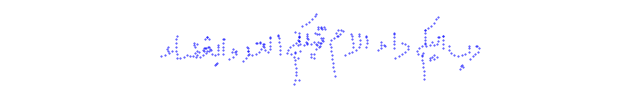

In [107]:
sample = process_sample('/content/hwd/Dataset/Data_2000/csv/csv_0004_2.csv')
print(len(sample))
plot_sample(sample)

In [118]:
sample_paths = open('/content/samples.txt').read().splitlines()
data = process_samples(sample_paths, out_dir='/content/processed/')

100%|██████████| 2403/2403 [01:10<00:00, 34.11it/s]


In [120]:
!ls /content/processed/ | tail -n 5

csv_6000_0042_3.npz
csv_6000_0042_4.npz
csv_6000_0042_5.npz
csv_6000_0042_6.npz
csv_6000_0042_7.npz


### Model